In [22]:
import sys
print(sys.path)

['/usr/lib/python314.zip', '/usr/lib/python3.14', '/usr/lib/python3.14/lib-dynload', '', '/home/swaraj/python/Plasma/ss/lib/python3.14/site-packages', '/home/swaraj/Git/Plasma']


In [23]:
import os
sys.path.append(os.path.abspath(".."))

In [24]:
print(os.getcwd())
print(os.path.abspath(".."))

/home/swaraj/Git/Plasma/DIIID
/home/swaraj/Git/Plasma


In [25]:
import psiBfield

g = psiBfield.extract_g("/home/swaraj/Git/Plasma/DIIID/DIIID_resources/g_file.in")
psi_norm, BR, Bphi, BZ = psiBfield.compute_B(g)

g_file keywords extracted
Psi Normalized and Magnetic field BR Bphi BZ computed.


In [26]:
import matplotlib.pyplot as plt
import numpy as np

In [27]:
with open('/home/swaraj/Git/Plasma/DTT/DTTN_resources/profile.in', 'r') as f:
    for i in range(3):
        print(f.readline())

   Pol-Flux            x              r              R               R+r             Te              ne              Ti            Zeff          omega-tor           Er              ni           nimp             nf              Tf

   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00   1.6894600e+03   3.2785200e+13   5.0683800e+03   1.9047600e+00   3.8310119e+01   0.0000000e+00   2.4907600e+13   9.8876100e+11   1.9451000e+12   2.3927400e+04

   1.0000000e-02   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00   1.6887900e+03   3.2675131e+13   5.0109182e+03   1.9021400e+00   3.8235161e+01   0.0000000e+00   2.4924800e+13   9.8586000e+11   1.9442100e+12   2.3927400e+04



In [28]:
profile = np.genfromtxt('/home/swaraj/Git/Plasma/DTT/DTTN_resources/profile.in', skip_header=1)

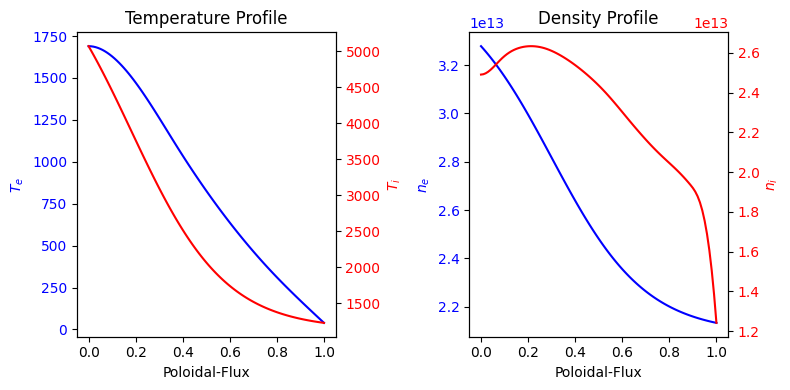

In [29]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

ax1 = plt.gca()
ax1.plot(profile[:,0], profile[:,5], 'b-', label='Te')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlabel('Poloidal-Flux')
ax1.set_ylabel(r'$T_e$', color='b')
ax1.set_title('Temperature Profile')
ax2 = ax1.twinx()
ax2.plot(profile[:,0], profile[:,7], 'r-', label='Ti')
ax2.set_ylabel(r'$T_i$', color='r')
ax2.tick_params(axis='y', labelcolor='r')


plt.subplot(1,2,2)

ax1 = plt.gca()
ax1.plot(profile[:,0], profile[:,6], 'b-', label='ne')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlabel('Poloidal-Flux')
ax1.set_ylabel(r'$n_e$', color='b')
ax1.set_title('Density Profile')
ax2 = ax1.twinx()
ax2.plot(profile[:,0], profile[:,11], 'r-', label='ni')
ax2.set_ylabel(r'$n_i$', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.tight_layout()
plt.show()

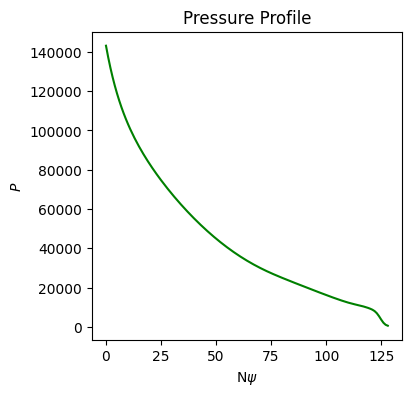

In [30]:
plt.figure(figsize=(4, 4))
plt.plot(g.pres, 'g-')
plt.xlabel(r'N$\psi$')
plt.ylabel(r'$P$')
plt.title('Pressure Profile')
plt.show()

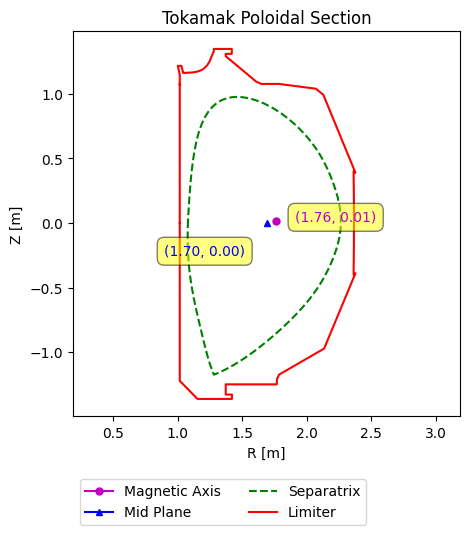

In [31]:
plt.figure(figsize=(5,5))
plt.plot(g.rmaxis, g.zmaxis, 'm', marker = 'o', markersize = 5, label = "Magnetic Axis")
plt.annotate(f"({g.rmaxis:.2f}, {g.zmaxis:.2f})", xy=(g.rmaxis, g.zmaxis), xytext=(g.rmaxis+0.15, g.zmaxis), color='m', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
plt.plot(g.rcentr, g.zmid, 'b',marker = '^', markersize = 5, label = "Mid Plane")
plt.annotate(f"({g.rcentr:.2f}, {g.zmid:.2f})", xy=(g.rcentr, g.zmid), xytext=(g.rcentr-0.8, g.zmid-0.25) ,color='b', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.plot(g.rlim, g.zlim, 'r', label = "Limiter")
plt.title("Tokamak Poloidal Section")
plt.xlim(g.r_grid[:,0][0], g.r_grid[:,0][-1])
plt.ylim(g.z_grid[0,:][0], g.z_grid[0,:][-1])
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='lower left', ncols = 2,bbox_to_anchor=(0, -0.3))
plt.show()

/tmp/ipykernel_263352/1801196969.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


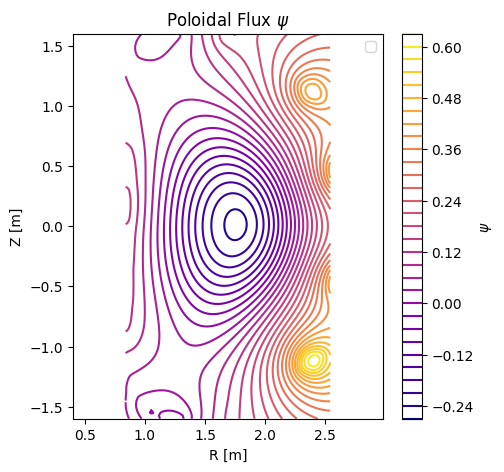

In [32]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, g.psi, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

/tmp/ipykernel_263352/1103649705.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


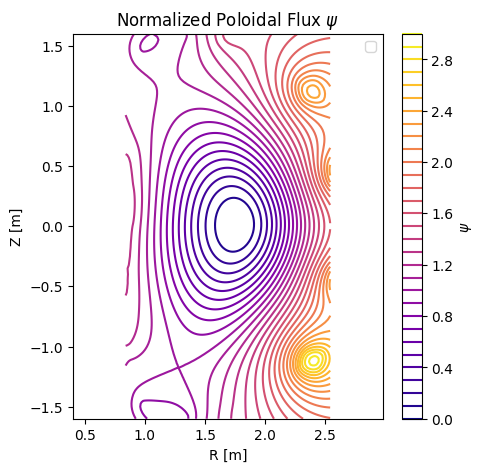

In [33]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, psi_norm, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Normalized Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

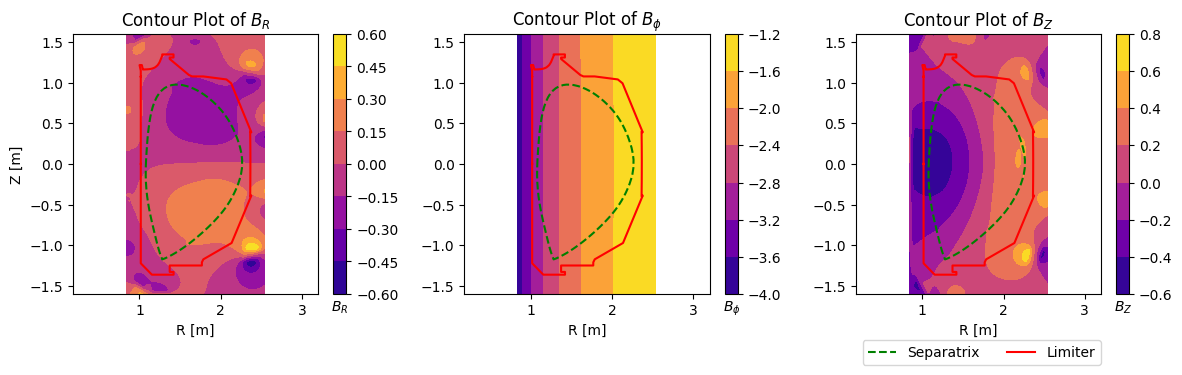

In [34]:
plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.contourf(g.r_grid, g.z_grid, BR, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_R$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_R$')

plt.subplot(1,3,2)
plt.contourf(g.r_grid, g.z_grid, Bphi, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_\phi$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
# plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_{\phi}$')

plt.subplot(1,3,3)
plt.contourf(g.r_grid, g.z_grid, BZ, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_Z$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
# plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.legend(loc='lower left', ncols=2, bbox_to_anchor=(0,-0.3))
plt.title(r'Contour Plot of $B_Z$')

plt.tight_layout()
plt.show()


# Field Tracing

In [35]:
rtraj, ztraj = psiBfield.field_tracing(g, psi_norm, BR, BZ)

User inputs received. 
          r_start = 1.80906803, r_end = 2.25362316, N = 10, initial_h = -0.001, tolerance = 0.01, max_step = 60000.
          Starting field line tracing...
Trajectory 1/10 Step 1 : r = 1.8091, z = 0.0118, psi = 0.0109, h = -1.00e-03
Trajectory 1/10 Step 2 : r = 1.8090, z = 0.0109, psi = 0.0109, h = -1.00e-03
Trajectory 1/10 Step 3 : r = 1.8090, z = 0.0099, psi = 0.0109, h = -1.00e-03
Trajectory 1/10 Step 4 : r = 1.8089, z = 0.0089, psi = 0.0109, h = -1.00e-03
Trajectory 1/10 Step 5 : r = 1.8089, z = 0.0079, psi = 0.0109, h = -1.00e-03
Trajectory 1/10 Step 6 : r = 1.8088, z = 0.0069, psi = 0.0108, h = -1.00e-03
Trajectory 1/10 Step 7 : r = 1.8087, z = 0.0059, psi = 0.0108, h = -1.00e-03
Trajectory 1/10 Step 8 : r = 1.8086, z = 0.0049, psi = 0.0108, h = -1.00e-03
Trajectory 1/10 Step 9 : r = 1.8085, z = 0.0039, psi = 0.0108, h = -1.00e-03
Trajectory 1/10 Step 10 : r = 1.8084, z = 0.0029, psi = 0.0107, h = -1.00e-03
Trajectory 1/10 Step 11 : r = 1.8083, z = 0.0019,

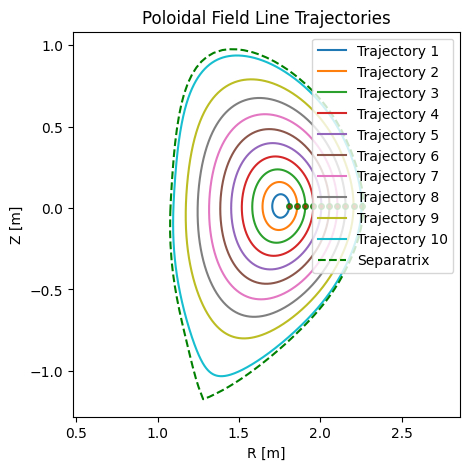

In [36]:
plt.figure(figsize=(5, 5))
for i in range(len(rtraj)):
    plt.plot(rtraj[i], ztraj[i], label = f"Trajectory {i+1}")
    plt.plot(rtraj[i][0], ztraj[i][0], 'go', markersize=4, alpha=0.8)
    plt.plot(rtraj[i][-1], ztraj[i][-1], 'ro', markersize=2, alpha=0.4)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Poloidal Field Line Trajectories")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [ ]:
r_grid_points, z_grid_points = psiBfield.grid_points(rtraj, ztraj)

Cumulative distances along trajectories computed.


In [ ]:
plt.figure(figsize=(5, 5))
for i in range(len(r_grid_points)):
    point_plot = plt.plot(r_grid_points[i], z_grid_points[i], 'x', markersize=5)
    color_i = point_plot[0].get_color()
    plt.plot(rtraj[i], ztraj[i], alpha = 0.5, color=color_i)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Grid Points on Poloidal Plane")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [ ]:
r_array = np.concatenate(r_grid_points)
z_array = np.concatenate(z_grid_points)

points = np.column_stack((r_array, z_array))

from scipy.spatial import Delaunay

tri = Delaunay(points)

In [ ]:
plt.figure(figsize=(5,5))
plt.triplot(points[:,0], points[:,1], tri.simplices, color='gray', markersize=2)
plt.plot(points[:,0], points[:,1], 'ko', markersize=2)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Delaunay Triangulation with Hole")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [ ]:
hole_radius = 0.12

filtered_triangles_with_hole = []

for tri_indices in tri.simplices:
    p1, p2, p3 = points[tri_indices]

    centroid_r, centroid_z = (p1 + p2 + p3) / 3

    distance = np.sqrt((centroid_r - g.rmaxis)**2 + (centroid_z - g.zmaxis)**2)

    if distance > hole_radius:
        # print(f"Triangle with vertices {p1}, {p2}, {p3} is too close to the magnetic axis and will be removed.")
        filtered_triangles_with_hole.append(tri_indices)

filtered_triangles_with_hole = np.array(filtered_triangles_with_hole)

In [ ]:
plt.figure(figsize=(5,5))
plt.triplot(points[:,0], points[:,1], filtered_triangles_with_hole, color='gray', markersize=2)
plt.plot(points[:,0], points[:,1], 'ko', markersize=2)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Delaunay Triangulation with Hole")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# ===================
# Interpolators
# ===================

BR_interp = RegularGridInterpolator((g.r_grid[:,0], g.z_grid[0,:]), BR)
BZ_interp = RegularGridInterpolator((g.r_grid[:,0], g.z_grid[0,:]), BZ)
psi_interp = RegularGridInterpolator((g.r_grid[:,0], g.z_grid[0,:]), psi_norm)


# =========================
# Field Line Equation
#==========================

def F(r_current, z_current):
    if not (g.rbdry.min()-0.01 <= r_current <= g.rbdry.max()+0.01 and
        g.zbdry.min()-0.01 <= z_current <= g.zbdry.max()+0.01):
        return np.nan, np.nan
    
    BR_local = BR_interp((r_current, z_current))
    BZ_local = BZ_interp((r_current, z_current))
    Bp_local = np.sqrt(BR_local**2 + BZ_local**2)
    if Bp_local == 0.0:
        br = 0.0
        bz = 0.0
    else:
        br = BR_local/Bp_local
        bz = BZ_local/Bp_local
    return br, bz


#=========================
# RK4 Implementation
#=========================

def RK4(F, r_current, z_current, h):
    k1r, k1z = F(r_current, z_current)
    if np.isnan(k1r) or np.isnan(k1z): return np.nan, np.nan

    k2r, k2z = F(r_current + 0.5*h*k1r, z_current + 0.5*h*k1z)
    if np.isnan(k2r) or np.isnan(k2z): return np.nan, np.nan

    k3r, k3z = F(r_current + 0.5*h*k2r, z_current + 0.5*h*k2z)
    if np.isnan(k3r) or np.isnan(k3z): return np.nan, np.nan

    k4r, k4z = F(r_current + h*k3r, z_current + h*k3z)
    if np.isnan(k4r) or np.isnan(k4z): return np.nan, np.nan

    r_new = r_current + (h/6)*(k1r + 2*k2r + 2*k3r + k4r)
    z_new = z_current + (h/6)*(k1z + 2*k2z + 2*k3z + k4z)
    return r_new, z_new


# =========================
# initial cinditions
# =========================

r_start = g.rbdry.max()
z_start = g.zmaxis

psi_current = psi_interp((r_start, z_start))

r_trajectory_f = []
z_trajectory_f = []

step_count = 0
diff_angle = 0.0

initial_h = -1e-6

tolerance = 1e-4

max_step = 10000000

print(f"""User inputs received. 
          r_start = {r_start},  initial_h = {initial_h}, tolerance = {tolerance}, max_step = {max_step}.
          Starting Last Field Line Tracing...""")

while (step_count < max_step):
        

        step_count += 1
        h_current_step = initial_h

        angle_initial = np.arctan2(z_start - g.zmaxis, r_start - g.rmaxis) + np.pi
        refined_step_found = False
        for _ in range(15):
            r_trial, z_trial = RK4(F, r_start, z_start, h_current_step)

            psi_trial = psi_interp((r_trial, z_trial))

            if abs(psi_trial - psi_current) < tolerance:
                refined_step_found = True
                r_start, z_start = r_trial, z_trial
                break
            else:
                h_current_step /= 2.0
                if h_current_step < 1e-10:
                    refined_step_found = True
                    r_start, z_start = r_trial, z_trial
                    break

        angle_trial = np.arctan2(z_trial - g.zmaxis, r_trial - g.rmaxis) + np.pi

        diff_angle += abs(angle_initial - angle_trial)

        if diff_angle >= 4*np.pi:
            break

        r_current, z_current = r_start, z_start

        r_trajectory_f.append(r_start)
        z_trajectory_f.append(z_start)
        print(f"Step {step_count} : r = {r_current:.4f}, z = {z_current:.4f}, psi = {psi_trial:.4f}, h = {h_current_step:.2e}")    
